# 01. Descarga y Mapeo de Estructuras Proteicas

## Objetivo
Documentar y ejecutar el pipeline de descarga de estructuras proteicas experimentales (PDB)
y predicciones computacionales (AlphaFold), utilizando el mapeo SIFTS como puente entre ambas bases de datos.

## Fuentes de Datos

| Base de Datos | Tipo | URL | Contenido |
|---|---|---|---|
| **RCSB PDB** | Experimental | rcsb.org | Estructuras 3D determinadas por cristalografía, NMR, cryo-EM |
| **AlphaFold EBI** | Predicción | alphafold.ebi.ac.uk | Modelos predichos por AlphaFold2 a partir de secuencia |
| **SIFTS** | Mapeo | ebi.ac.uk/pdbe/docs/sifts | Correspondencia PDB ↔ UniProt |

### ¿Qué es SIFTS?
SIFTS (Structure Integration with Function, Taxonomy and Sequences) es un recurso del EBI que
proporciona mapeos residuo a residuo entre entradas PDB y secuencias UniProt. Esto nos permite
saber qué estructura experimental corresponde a qué proteína predicha por AlphaFold.

### ¿Por qué es necesario este mapeo?
- PDB usa identificadores de 4 caracteres (ej: 1UBQ) + cadena (ej: A)
- AlphaFold usa identificadores UniProt (ej: P0CG47)
- Una misma proteína puede tener múltiples entradas PDB (diferentes cristales, resoluciones)
- SIFTS nos da la correspondencia correcta entre ambos sistemas

In [1]:
import sys
from pathlib import Path

# Agregar src/ al path para importar el paquete
sys.path.insert(0, str(Path("..") / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from alphafold_comparison.config import Config

Config.summary()

Configuración del proyecto
  PROJECT_ROOT:    /home/antonio-tapia/alphafold-project
  DATA_DIR:        /home/antonio-tapia/alphafold-project/data
  SIFTS_FILE:      /home/antonio-tapia/alphafold-project/data/raw/mappings/pdb_chain_uniprot.csv
  Workers:         8
  Min residues:    3
  Min common res:  10


## Inventario de Datos Descargados

Verificamos el estado actual de los datos descargados.

In [2]:
# Contar archivos descargados
pdb_files = list(Config.PDB_DIR.glob("*.ent")) if Config.PDB_DIR.exists() else []
af_files = list(Config.AF_DIR.glob("*.pdb")) if Config.AF_DIR.exists() else []

print(f"Archivos PDB descargados: {len(pdb_files):,}")
print(f"Archivos AlphaFold descargados: {len(af_files):,}")

# Cargar lista de pares exitosos
if Config.ID_LIST.exists():
    id_list = pd.read_csv(Config.ID_LIST)
    print(f"\nPares exitosos (id_list.csv): {len(id_list):,}")
    print(f"PDB IDs unicos: {id_list['PDB'].nunique():,}")
    print(f"UniProt IDs unicos: {id_list['SP_PRIMARY'].nunique():,}")
    display(id_list.head(10))
else:
    print("id_list.csv no encontrado. Ejecutar: make download")

Archivos PDB descargados: 38,786
Archivos AlphaFold descargados: 12,847

Pares exitosos (id_list.csv): 11,384
PDB IDs unicos: 10,945
UniProt IDs unicos: 11,384


,PDB,SP_PRIMARY,CHAIN
0,7WJI,Q9P2D8,B
1,9NJU,Q869W9,A
2,6ZWM,P42345,A
3,8VDP,P26039,A
4,6R9T,Q9Y490,A
5,5GMK,P33334,A
6,9B8S,Q07864,A
7,7TC0,O95477,A
8,8FHS,Q13936,A
9,7KVF,P12259,B


## Estructura de los Archivos

### Formato PDB (Protein Data Bank)
Los archivos `.ent` contienen coordenadas atómicas en formato PDB:
- Líneas `ATOM`: coordenadas x,y,z de cada átomo
- Líneas `HETATM`: heteroátomos (ligandos, agua, cofactores)
- Metadatos: resolución, método experimental, autores

### Formato AlphaFold
Los modelos AlphaFold usan el mismo formato PDB pero incluyen:
- Solo la cadena predicha (sin ligandos ni agua)
- Campo B-factor repurposeado como **pLDDT** (confianza de predicción, 0-100)
- Estructura completa de la secuencia UniProt

In [3]:
# Ejemplo: examinar un archivo PDB y su par AlphaFold
if len(pdb_files) > 0 and len(af_files) > 0:
    example_pdb = pdb_files[0]
    print(f"Ejemplo PDB: {example_pdb.name}")
    print(f"Tamano: {example_pdb.stat().st_size / 1024:.1f} KB")
    print("\nPrimeras 10 lineas:")
    with open(example_pdb) as f:
        for i, line in enumerate(f):
            if i < 10:
                print(f"  {line.rstrip()}")
            else:
                break

Ejemplo PDB: pdb8a7o.ent
Tamano: 372.3 KB

Primeras 10 lineas:
  HEADER    PROTEIN FIBRIL                          21-JUN-22   8A7O
  TITLE     BETA-2-MICROGLOBULIN DELTAN6 AMYLOID FIBRIL FORM 2PFA
  COMPND    MOL_ID: 1;
  COMPND   2 MOLECULE: BETA-2-MICROGLOBULIN FORM PI 5.3;
  COMPND   3 CHAIN: A, B, C, D, E, F;
  COMPND   4 ENGINEERED: YES;
  COMPND   5 MUTATION: YES;
  COMPND   6 OTHER_DETAILS: NATURALLY OCCURING DELTAN6 VARIANT WITH METHIONINE
  COMPND   7 ADDED PRIOR TO PEPTIDE SEQUENCE TO INITIATE BACTERIAL EXPRESSION.
  SOURCE    MOL_ID: 1;


## Distribución de Pares

Analizamos la distribución de los pares descargados.

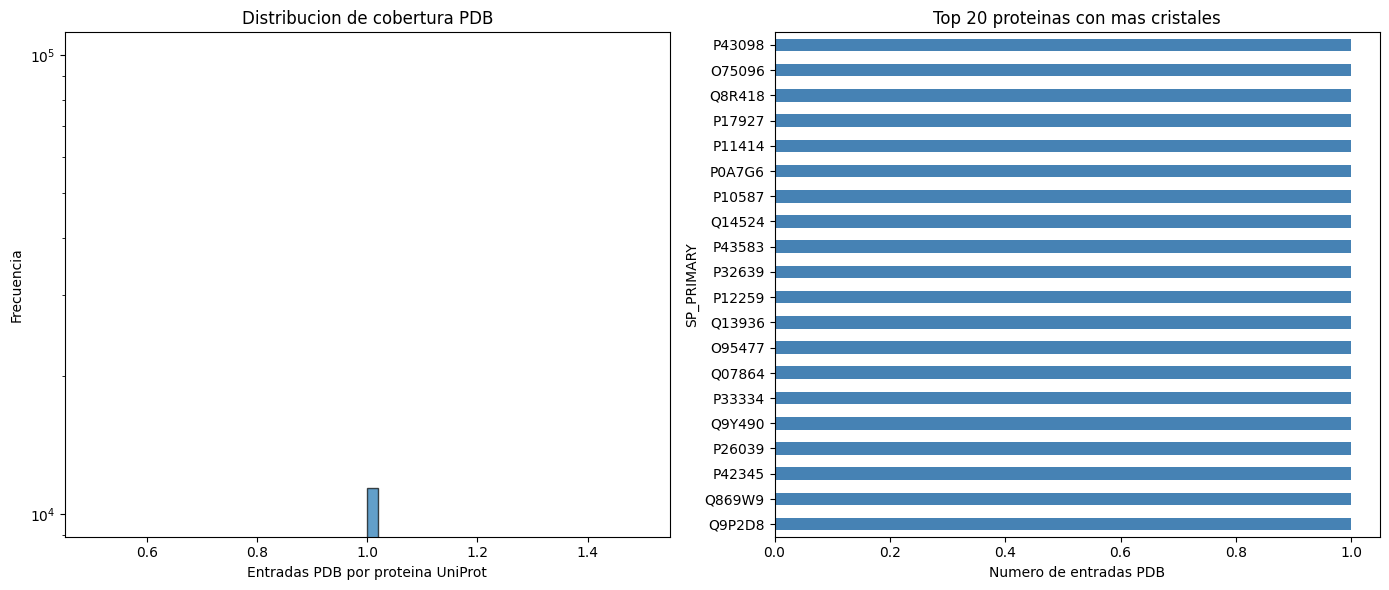

In [4]:
if Config.ID_LIST.exists():
    id_list = pd.read_csv(Config.ID_LIST)
    
    # Proteinas con mas entradas PDB
    top_uniprot = id_list['SP_PRIMARY'].value_counts().head(20)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Distribucion de entradas por UniProt
    entries_per_uniprot = id_list['SP_PRIMARY'].value_counts()
    axes[0].hist(entries_per_uniprot.values, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Entradas PDB por proteina UniProt')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribucion de cobertura PDB')
    axes[0].set_yscale('log')
    
    # Top proteinas
    top_uniprot.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_xlabel('Numero de entradas PDB')
    axes[1].set_title('Top 20 proteinas con mas cristales')
    
    plt.tight_layout()
    plt.savefig('figures/distribucion_pares.png', dpi=150, bbox_inches='tight')
    plt.show()

## Ejecución de la Descarga

Para ejecutar o re-ejecutar la descarga:

```bash
# Desde la raiz del proyecto
make download

# O directamente
python -m alphafold_comparison download --target 50000 --workers 15
```

## Siguiente Paso

→ [02_validacion_pares.ipynb](02_validacion_pares.ipynb): Validar que los pares descargados realmente corresponden a la misma proteína.